<a href="https://colab.research.google.com/github/sayonmitra-tech/AI_Blood_Group_detection/blob/main/AI_Blood_Group_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Blood Group Detection.v4i.coco.zip to Blood Group Detection.v4i.coco.zip


In [ ]:
import zipfile
import os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Extracted!")

Extracted!


In [ ]:
!ls data

README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!pip install opencv-python

In [ ]:
import os
import cv2
import json

def process_folder(folder):
    annotation_file = f"data/{folder}/_annotations.coco.json"

    with open(annotation_file) as f:
        coco = json.load(f)

    images = {img['id']: img for img in coco['images']}

    for ann in coco['annotations']:
        img_id = ann['image_id']
        bbox = ann['bbox']

        img_info = images[img_id]
        img_path = f"data/{folder}/" + img_info['file_name']

        img = cv2.imread(img_path)
        if img is None:
            continue

        x, y, w, h = map(int, bbox)
        crop = img[y:y+h, x:x+w]

        label = str(ann['category_id'])
        save_dir = f"dataset/{folder}/{label}"
        os.makedirs(save_dir, exist_ok=True)

        filename = f"{save_dir}/{img_id}.jpg"
        cv2.imwrite(filename, crop)

# Run for all sets
process_folder("train")
process_folder("valid")
process_folder("test")

print("Conversion Done!")

Conversion Done!


In [ ]:
import tensorflow as tf

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/train",
    image_size=(224,224),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/valid",
    image_size=(224,224),
    batch_size=32
)

Found 6456 files belonging to 3 classes.
Found 997 files belonging to 3 classes.


In [ ]:
print(train_data.class_names)

['1', '2', '3']



Class: 3


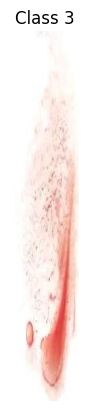

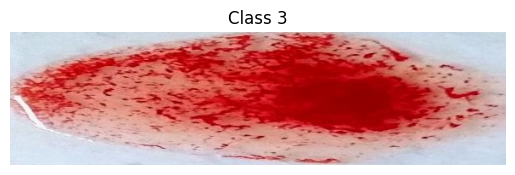

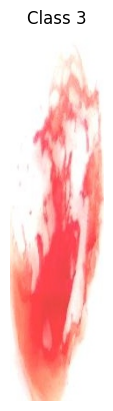


Class: 2


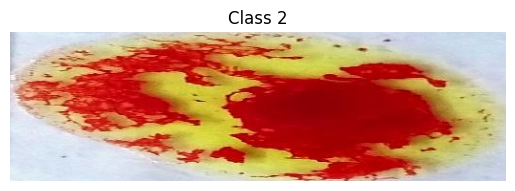

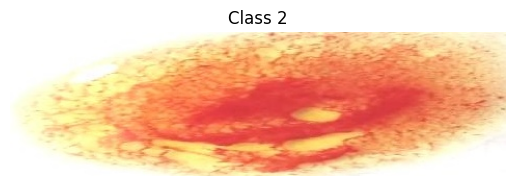

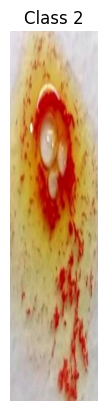


Class: 1


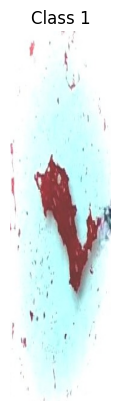

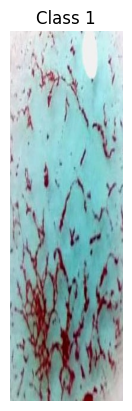

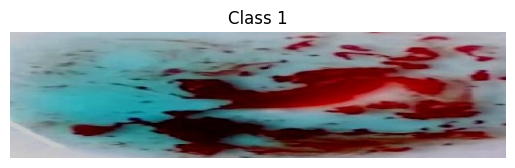

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2

base_path = "dataset/train"

classes = os.listdir(base_path)

for cls in classes:
    folder = os.path.join(base_path, cls)
    images = os.listdir(folder)[:3]  # take 3 samples

    print(f"\nClass: {cls}")

    for img_name in images:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title(f"Class {cls}")
        plt.axis("off")
        plt.show()

In [ ]:
def get_reaction(pred):
    class_id = pred.argmax()

    if class_id == 0:   # Class 1
        return 1  # Positive
    elif class_id == 1: # Class 2
        return 1  # Positive
    else:               # Class 3
        return 0  # Negative

In [ ]:
def get_blood_group(A_pred, B_pred, D_pred):

    A = get_reaction(A_pred)
    B = get_reaction(B_pred)
    D = get_reaction(D_pred)

    # ABO grouping
    if A == 1 and B == 0:
        group = "A"
    elif B == 1 and A == 0:
        group = "B"
    elif A == 1 and B == 1:
        group = "AB"
    else:
        group = "O"

    # Rh factor
    if D == 1:
        group += "+"
    else:
        group += "-"

    return group

In [ ]:
def predict_image(path):
    img = tf.keras.preprocessing.image.load_img(path, target_size=(224,224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.expand_dims(img, axis=0)

    pred = model.predict(img)
    return pred

In [ ]:
# example A_pred = predict_image("A.jpg")
B_pred = predict_image("B.jpg")
D_pred = predict_image("D.jpg")

print(get_blood_group(A_pred, B_pred, D_pred))


FileNotFoundError: [Errno 2] No such file or directory: 'B.jpg'

In [ ]:
from google.colab import files
uploaded = files.upload()


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
